In [1]:
# Section 1 — Imports + Load All Three Checkpoints

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Paths
PROJECT_ROOT = Path('..').resolve()
DATA_DIR = PROJECT_ROOT / 'data'
CHECKPOINTS_DIR = PROJECT_ROOT / 'checkpoints'
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
OUTPUTS_DIR.mkdir(exist_ok=True)

X_TEST_PICKLE = DATA_DIR / 'x_test.pkl'
KAGGLE_TEST_CSV = DATA_DIR / 'test.csv'

STAGE1_CHECKPOINT = CHECKPOINTS_DIR / 'stage1_reader_imagination.pt'
STAGE2_CHECKPOINT = CHECKPOINTS_DIR / 'stage2_concept_block.pt'
STAGE3_CHECKPOINT = CHECKPOINTS_DIR / 'stage3_decision_block.pt'

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Dimensions
INPUT_DIM = 13
LATENT_DIM = 32
CONCEPT_DIM = 6

FEATURE_NAMES = [
    'lap_time_norm', 'lap_time_delta', 'cumulative_degradation',
    'tyre_life_norm', 'compound_soft', 'compound_medium', 'compound_hard',
    'compound_inter', 'compound_wet', 'position_norm', 'position_change_norm',
    'race_progress', 'stint_norm',
]
CONCEPT_NAMES = [
    'degradation_severity', 'pace_decay_rate', 'strategic_window',
    'track_position_risk', 'undercut_pressure', 'endgame_proximity',
]


# ── Model classes
class Reader(nn.Module):
    def __init__(self, input_dim=INPUT_DIM, latent_dim=LATENT_DIM):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, latent_dim)
        self.ln1 = nn.LayerNorm(latent_dim)
        self.fc2 = nn.Linear(latent_dim, latent_dim)
        self.ln2 = nn.LayerNorm(latent_dim)
        self.fc3 = nn.Linear(latent_dim, latent_dim)
    def forward(self, x):
        h = F.relu(self.ln1(self.fc1(x)))
        h = F.relu(self.ln2(self.fc2(h)))
        return self.fc3(h)


class ConceptBlock(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM, concept_dim=CONCEPT_DIM, hidden_dim=16):
        super().__init__()
        self.fc1 = nn.Linear(latent_dim, hidden_dim)
        self.ln1 = nn.LayerNorm(hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, concept_dim)
    def forward(self, z):
        h = F.relu(self.ln1(self.fc1(z)))
        return torch.sigmoid(self.fc2(h))


class DecisionBlock(nn.Module):
    def __init__(self, concept_dim=CONCEPT_DIM):
        super().__init__()
        self.linear = nn.Linear(concept_dim, 1)
    def forward(self, c):
        logit = self.linear(c).squeeze(-1)
        pit_prob = torch.sigmoid(logit)
        return pit_prob, logit


# ── Load all three checkpoints
print("=" * 70)
print("LOADING ALL CHECKPOINTS")
print("=" * 70)

ckpt1 = torch.load(STAGE1_CHECKPOINT, weights_only=False)
ckpt2 = torch.load(STAGE2_CHECKPOINT, weights_only=False)
ckpt3 = torch.load(STAGE3_CHECKPOINT, weights_only=False)

reader = Reader().to(DEVICE)
reader.load_state_dict(ckpt1['reader_state_dict'])
reader.eval()

concept_block = ConceptBlock().to(DEVICE)
concept_block.load_state_dict(ckpt2['concept_block_state_dict'])
concept_block.eval()

decision_block = DecisionBlock().to(DEVICE)
decision_block.load_state_dict(ckpt3['decision_block_state_dict'])
decision_block.eval()

for blk in [reader, concept_block, decision_block]:
    for p in blk.parameters():
        p.requires_grad = False

print(f"\n  Reader         ({sum(p.numel() for p in reader.parameters()):>5,} params)  "
      f"Stage 1 best epoch {ckpt1['best_epoch']}, val_recon={ckpt1['best_val_recon']:.5f}")
print(f"  ConceptBlock   ({sum(p.numel() for p in concept_block.parameters()):>5,} params)  "
      f"Stage 2 best epoch {ckpt2['best_epoch']}, val_mse={ckpt2['best_val_mse']:.5f}")
print(f"  DecisionBlock  ({sum(p.numel() for p in decision_block.parameters()):>5,} params)  "
      f"Stage 3 best epoch {ckpt3['best_epoch']}, val_auc={ckpt3['best_val_auc']:.4f}")
total_params = sum(sum(p.numel() for p in blk.parameters()) for blk in [reader, concept_block, decision_block])
print(f"\n  Total inference parameters: {total_params:,}")


# ── Print final Decision Block weights (for the demo write-up)
print("\n" + "=" * 70)
print("FINAL DECISION BLOCK WEIGHTS (the interpretability artifact)")
print("=" * 70)
weights = decision_block.linear.weight[0].detach().cpu().numpy()
bias = decision_block.linear.bias.item()
print(f"\n  {'concept':<24s} | {'weight':>10s}")
print("-" * 40)
for j, name in enumerate(CONCEPT_NAMES):
    print(f"  {name:<22s} | {weights[j]:>+10.4f}")
print(f"  {'bias':<22s} | {bias:>+10.4f}")

LOADING ALL CHECKPOINTS

  Reader         (2,688 params)  Stage 1 best epoch 7, val_recon=0.20416
  ConceptBlock   (  662 params)  Stage 2 best epoch 15, val_mse=0.02273
  DecisionBlock  (    7 params)  Stage 3 best epoch 7, val_auc=0.7402

  Total inference parameters: 3,357

FINAL DECISION BLOCK WEIGHTS (the interpretability artifact)

  concept                  |     weight
----------------------------------------
  degradation_severity   |    +1.0731
  pace_decay_rate        |    -0.1885
  strategic_window       |    +1.1990
  track_position_risk    |    -0.2383
  undercut_pressure      |    +1.6079
  endgame_proximity      |    -2.9945
  bias                   |    -0.6079


RUNNING INFERENCE ON KAGGLE TEST SET

  Test rows:       188,165
  Feature dim:     13
  id range:        [439140, 627304]

Running inference (chunked)...
  Processed 50,000 / 188,165
  Processed 100,000 / 188,165
  Processed 150,000 / 188,165
  Processed 188,165 / 188,165

  Inference complete in 0.9s

INFERENCE SANITY CHECKS

  test_z shape:       (188165, 32)  (NaN: False)
  test_c shape:       (188165, 6)  (NaN: False)
  test_probs shape:   (188165,)  (NaN: False)
  test_probs range:   [0.0651, 0.9479]
  test_probs mean:    0.4534  (Kaggle train pit rate was 0.199)

DISTRIBUTION OF PREDICTED PROBABILITIES (Kaggle test)

  p10:  0.3169
  p25:  0.3412
  p50:  0.3825
  p75:  0.5398
  p90:  0.7294
  p95:  0.8097
  p99:  0.8876

  Frac predicted > 0.5: 29.75%
  Frac predicted > 0.7: 12.05%
  Frac predicted > 0.9: 0.64%


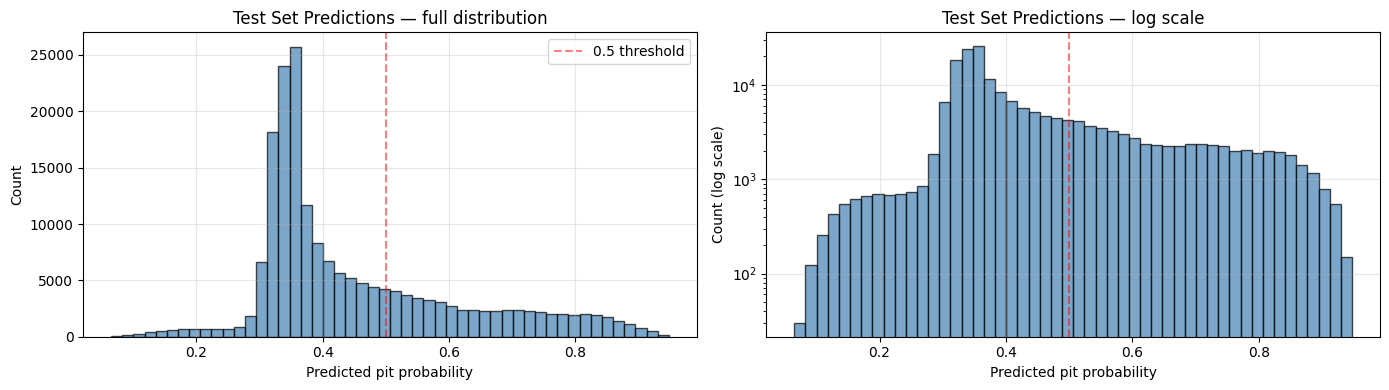

In [2]:
# Section 2 — Run Inference on Kaggle Test Set

print("=" * 70)
print("RUNNING INFERENCE ON KAGGLE TEST SET")
print("=" * 70)

# Load test data (already preprocessed in Notebook 01)
x_test_df = pd.read_pickle(X_TEST_PICKLE)
x_cols = [f'x_{n}' for n in FEATURE_NAMES]
x_test_arr = x_test_df[x_cols].values.astype(np.float32)
test_ids = x_test_df['id'].values

print(f"\n  Test rows:       {len(x_test_arr):,}")
print(f"  Feature dim:     {x_test_arr.shape[1]}")
print(f"  id range:        [{test_ids.min()}, {test_ids.max()}]")


# ── Run through Reader → ConceptBlock → DecisionBlock
print("\nRunning inference (chunked)...")
t_start = time.time()

chunk_size = 50000
all_z, all_c, all_probs, all_logits = [], [], [], []

with torch.no_grad():
    x_tensor = torch.from_numpy(x_test_arr).to(DEVICE)
    for i in range(0, len(x_tensor), chunk_size):
        chunk = x_tensor[i:i+chunk_size]
        z = reader(chunk)
        c = concept_block(z)
        pit_prob, logit = decision_block(c)
        all_z.append(z.cpu().numpy())
        all_c.append(c.cpu().numpy())
        all_probs.append(pit_prob.cpu().numpy())
        all_logits.append(logit.cpu().numpy())
        print(f"  Processed {min(i+chunk_size, len(x_tensor)):,} / {len(x_tensor):,}")

test_z = np.concatenate(all_z, axis=0)
test_c = np.concatenate(all_c, axis=0)
test_probs = np.concatenate(all_probs, axis=0)
test_logits = np.concatenate(all_logits, axis=0)

print(f"\n  Inference complete in {time.time() - t_start:.1f}s")


# ── Sanity checks
print("\n" + "=" * 70)
print("INFERENCE SANITY CHECKS")
print("=" * 70)

print(f"\n  test_z shape:       {test_z.shape}  (NaN: {np.isnan(test_z).any()})")
print(f"  test_c shape:       {test_c.shape}  (NaN: {np.isnan(test_c).any()})")
print(f"  test_probs shape:   {test_probs.shape}  (NaN: {np.isnan(test_probs).any()})")
print(f"  test_probs range:   [{test_probs.min():.4f}, {test_probs.max():.4f}]")
print(f"  test_probs mean:    {test_probs.mean():.4f}  (Kaggle train pit rate was 0.199)")


# ── Distribution of predicted probabilities
print("\n" + "=" * 70)
print("DISTRIBUTION OF PREDICTED PROBABILITIES (Kaggle test)")
print("=" * 70)

deciles = np.percentile(test_probs, [10, 25, 50, 75, 90, 95, 99])
print(f"\n  p10:  {deciles[0]:.4f}")
print(f"  p25:  {deciles[1]:.4f}")
print(f"  p50:  {deciles[2]:.4f}")
print(f"  p75:  {deciles[3]:.4f}")
print(f"  p90:  {deciles[4]:.4f}")
print(f"  p95:  {deciles[5]:.4f}")
print(f"  p99:  {deciles[6]:.4f}")
print(f"\n  Frac predicted > 0.5: {(test_probs > 0.5).mean() * 100:.2f}%")
print(f"  Frac predicted > 0.7: {(test_probs > 0.7).mean() * 100:.2f}%")
print(f"  Frac predicted > 0.9: {(test_probs > 0.9).mean() * 100:.2f}%")

# Quick histogram
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].hist(test_probs, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('Predicted pit probability'); axes[0].set_ylabel('Count')
axes[0].set_title('Test Set Predictions — full distribution')
axes[0].axvline(0.5, color='red', linestyle='--', alpha=0.5, label='0.5 threshold')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].hist(test_probs, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[1].set_xlabel('Predicted pit probability'); axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Test Set Predictions — log scale')
axes[1].set_yscale('log')
axes[1].axvline(0.5, color='red', linestyle='--', alpha=0.5)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [3]:
# Section 3 — Build the Audit Trail Demo

print("=" * 70)
print("BUILDING AUDIT TRAIL DEMO")
print("=" * 70)

# Load raw test data so we have human-readable fields for the demo
kaggle_test_raw = pd.read_csv(KAGGLE_TEST_CSV)
kaggle_test_raw.columns = kaggle_test_raw.columns.str.strip()
assert (kaggle_test_raw['id'].values == test_ids).all(), "id alignment broken"
print(f"\n  Raw test loaded: {len(kaggle_test_raw):,} rows")

# Extract weights again for clean reference
weights = decision_block.linear.weight[0].detach().cpu().numpy()
bias = decision_block.linear.bias.item()


def format_audit_trail(sample_idx, label):
    """Build a human-readable audit trail for one test row."""
    row = kaggle_test_raw.iloc[sample_idx]
    concepts = test_c[sample_idx]
    prob = test_probs[sample_idx]
    logit = test_logits[sample_idx]
    
    lines = []
    lines.append(f"\n{'═' * 78}")
    lines.append(f"  EXAMPLE {label}")
    lines.append(f"{'═' * 78}")
    
    # Input snapshot
    lines.append(f"\n  Input row (id={int(row['id'])}):")
    lines.append(f"    Driver:        {row['Driver']}")
    lines.append(f"    Race:          {row['Race']} {int(row['Year'])}")
    lines.append(f"    Lap:           {int(row['LapNumber'])}  (Stint {int(row['Stint'])}, "
                 f"RaceProgress {row['RaceProgress']:.2f})")
    lines.append(f"    Compound:      {row['Compound']}  (TyreLife={int(row['TyreLife'])})")
    lines.append(f"    Position:      P{int(row['Position'])}  (recent change: {int(row['Position_Change']):+d})")
    lines.append(f"    Lap time:      {row['LapTime (s)']:.3f}s  "
                 f"(delta {row['LapTime_Delta']:+.3f}, cumulative_deg {row['Cumulative_Degradation']:+.2f})")
    
    # Concept readout
    lines.append(f"\n  What PRISM-F1 perceives (6 named concepts):")
    for j, name in enumerate(CONCEPT_NAMES):
        bar = "█" * int(round(concepts[j] * 20))
        lines.append(f"    {name:<22s}  {concepts[j]:.4f}  {bar}")
    
    # Per-concept contribution to the logit
    lines.append(f"\n  How the decision is built (additive concept contributions):")
    lines.append(f"    {'concept':<22s}  {'value':>8s} × {'weight':>8s}  =  {'contribution':>14s}")
    lines.append(f"    {'-' * 70}")
    running_total = 0.0
    for j, name in enumerate(CONCEPT_NAMES):
        contrib = concepts[j] * weights[j]
        running_total += contrib
        arrow = "→ pit" if contrib > 0.05 else ("→ stay" if contrib < -0.05 else "—")
        lines.append(f"    {name:<22s}  {concepts[j]:>8.4f} × {weights[j]:>+8.4f}  =  {contrib:>+14.4f}  {arrow}")
    lines.append(f"    {'bias':<22s}  {'':>8s} × {'':>8s}  =  {bias:>+14.4f}")
    lines.append(f"    {'-' * 70}")
    lines.append(f"    {'TOTAL LOGIT':<22s}  {'':>8s}   {'':>8s}     {running_total + bias:>+14.4f}")
    lines.append(f"    {'sigmoid(logit) = pit_prob':<22s}  {'':>8s}   {'':>8s}     {prob:>14.4f}")
    
    # Plain-language summary — pick the top 2 contributing concepts
    contributions = concepts * weights
    abs_contributions = np.abs(contributions)
    top2 = np.argsort(abs_contributions)[::-1][:2]
    decision_word = "PIT" if prob >= 0.5 else "STAY OUT"
    lines.append(f"\n  Verdict: PRISM-F1 predicts {decision_word} (probability {prob:.3f})")
    drivers_str = " and ".join(
        f"{CONCEPT_NAMES[j]} ({contributions[j]:+.2f})" for j in top2
    )
    lines.append(f"  Primary drivers: {drivers_str}")
    
    return "\n".join(lines)


# ── Pick 5 examples that tell different stories
print("\nSelecting 5 examples that illustrate different decision modes...")

# 1. Confident PIT — highest probability
idx_pit_confident = int(np.argmax(test_probs))

# 2. Confident NO PIT — lowest probability
idx_nopit_confident = int(np.argmin(test_probs))

# 3. Borderline — closest to 0.5
idx_borderline = int(np.argmin(np.abs(test_probs - 0.5)))

# 4. Strong endgame signal — RaceProgress > 0.9, predicted low
endgame_mask = (kaggle_test_raw['RaceProgress'] > 0.9).values & (test_probs < 0.3)
if endgame_mask.any():
    candidates = np.where(endgame_mask)[0]
    # Pick one with the most extreme endgame concept
    idx_endgame = int(candidates[np.argmax(test_c[candidates, 5])])
else:
    idx_endgame = int(np.argmin(test_probs[(kaggle_test_raw['RaceProgress'] > 0.85).values]))

# 5. Strong undercut signal — mid-race, undercut_pressure concept high
midrace_mask = ((kaggle_test_raw['RaceProgress'] > 0.3) & 
                (kaggle_test_raw['RaceProgress'] < 0.7)).values
undercut_scores = test_c[:, 4].copy()
undercut_scores[~midrace_mask] = -1
idx_undercut = int(np.argmax(undercut_scores))


# Build all 5 audit trails
examples = [
    (idx_pit_confident,    "1 / 5  —  CONFIDENT PIT PREDICTION"),
    (idx_nopit_confident,  "2 / 5  —  CONFIDENT STAY-OUT PREDICTION"),
    (idx_borderline,       "3 / 5  —  BORDERLINE 50/50 CALL"),
    (idx_endgame,          "4 / 5  —  STRONG END-OF-RACE ANTI-PIT SIGNAL"),
    (idx_undercut,         "5 / 5  —  STRONG UNDERCUT-PRESSURE PIT SIGNAL"),
]

full_demo = []
for sample_idx, label in examples:
    trail = format_audit_trail(sample_idx, label)
    full_demo.append(trail)
    print(trail)

# Save the audit trail demo to a file for the write-up
demo_path = OUTPUTS_DIR / 'audit_trail_demo.md'
with open(demo_path, 'w', encoding='utf-8') as f:
    f.write("# PRISM-F1 Audit Trail Demo\n\n")
    f.write("This document shows the per-prediction reasoning produced by PRISM-F1 ")
    f.write("for five test examples. Each prediction is decomposable into its 6 ")
    f.write("interpretable concept contributions plus a bias.\n\n")
    f.write("```\n")
    for trail in full_demo:
        f.write(trail)
        f.write("\n")
    f.write("```\n\n")
    f.write("## Final Decision Block Weights\n\n")
    f.write("| Concept | Weight |\n")
    f.write("|---|---|\n")
    for j, name in enumerate(CONCEPT_NAMES):
        f.write(f"| {name} | {weights[j]:+.4f} |\n")
    f.write(f"| **bias** | {bias:+.4f} |\n")

print(f"\n\n  Demo saved to: {demo_path}")

BUILDING AUDIT TRAIL DEMO

  Raw test loaded: 188,165 rows

Selecting 5 examples that illustrate different decision modes...

══════════════════════════════════════════════════════════════════════════════
  EXAMPLE 1 / 5  —  CONFIDENT PIT PREDICTION
══════════════════════════════════════════════════════════════════════════════

  Input row (id=453708):
    Driver:        COL
    Race:          Spanish Grand Prix 2025
    Lap:           33  (Stint 2, RaceProgress 0.43)
    Compound:      MEDIUM  (TyreLife=29)
    Position:      P14  (recent change: +3)
    Lap time:      83.873s  (delta +1.839, cumulative_deg -50.31)

  What PRISM-F1 perceives (6 named concepts):
    degradation_severity    0.9400  ███████████████████
    pace_decay_rate         0.0694  █
    strategic_window        0.7950  ████████████████
    track_position_risk     0.1622  ███
    undercut_pressure       0.9940  ████████████████████
    endgame_proximity       0.0000  

  How the decision is built (additive concept c

In [4]:
# Section 4 — Build and Save the Submission CSV

print("=" * 70)
print("BUILDING SUBMISSION CSV")
print("=" * 70)

# Build the submission dataframe
submission = pd.DataFrame({
    'id': test_ids,
    'PitNextLap': test_probs.astype(np.float32),
})

# Sort by id for safety
submission = submission.sort_values('id').reset_index(drop=True)

print(f"\n  Submission shape:  {submission.shape}")
print(f"  Columns:           {list(submission.columns)}")
print(f"  First 5 rows:")
print(submission.head().to_string(index=False))
print(f"\n  Last 5 rows:")
print(submission.tail().to_string(index=False))


# Sanity checks
print("\n" + "=" * 70)
print("SUBMISSION SANITY CHECKS")
print("=" * 70)
print(f"\n  Any NaN in PitNextLap?     {submission['PitNextLap'].isna().any()}")
print(f"  Any value < 0?             {(submission['PitNextLap'] < 0).any()}")
print(f"  Any value > 1?             {(submission['PitNextLap'] > 1).any()}")
print(f"  Probability range:         [{submission['PitNextLap'].min():.4f}, {submission['PitNextLap'].max():.4f}]")
print(f"  Probability mean:          {submission['PitNextLap'].mean():.4f}")
print(f"  id range:                  [{submission['id'].min()}, {submission['id'].max()}]")
print(f"  id unique count:           {submission['id'].nunique()}  (should equal row count {len(submission)})")
print(f"  Number of rows:            {len(submission):,}  (should equal 188,165)")


# Save
submission_path = OUTPUTS_DIR / 'submission.csv'
submission.to_csv(submission_path, index=False)
print(f"\n  Submission saved to: {submission_path}")
print(f"  File size: {submission_path.stat().st_size / 1024:.1f} KB")

BUILDING SUBMISSION CSV

  Submission shape:  (188165, 2)
  Columns:           ['id', 'PitNextLap']
  First 5 rows:
    id  PitNextLap
439140    0.705477
439141    0.736969
439142    0.667499
439143    0.360117
439144    0.823515

  Last 5 rows:
    id  PitNextLap
627300    0.361698
627301    0.284333
627302    0.865380
627303    0.392779
627304    0.524711

SUBMISSION SANITY CHECKS

  Any NaN in PitNextLap?     False
  Any value < 0?             False
  Any value > 1?             False
  Probability range:         [0.0651, 0.9479]
  Probability mean:          0.4534
  id range:                  [439140, 627304]
  id unique count:           188165  (should equal row count 188165)
  Number of rows:            188,165  (should equal 188,165)

  Submission saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\outputs\submission.csv
  File size: 3413.3 KB


In [4]:
def translate_concept(concept_idx, score):
    """Map a concept score to a plain-language strategic phrase.
    
    Args:
        concept_idx: integer 0-5 indicating which concept
            0 = degradation_severity
            1 = pace_decay_rate
            2 = strategic_window
            3 = track_position_risk
            4 = undercut_pressure
            5 = endgame_proximity
        score: float in [0, 1], the concept value
    
    Returns:
        A single plain-language string describing what this score means.
    """
    
    if concept_idx == 0:   # degradation_severity
        if score >= 0.7:
            return "The tyres are near or past their cliff — wear is severe."
        elif score >= 0.4:
            return "The tyres are worn but still working."
        elif score >= 0.15:
            return "The tyres show early signs of wear."
        else:
            return "The tyres are still relatively fresh."
    
    elif concept_idx == 1:   # pace_decay_rate
        if score >= 0.5:
            return "Lap pace is dropping noticeably from one lap to the next."
        elif score >= 0.2:
            return "Some pace decay is visible, but not dramatic."
        else:
            return "Lap pace is essentially stable."
    
    elif concept_idx == 2:   # strategic_window
        if score >= 0.7:
            return "We are deep in the typical pit window for this compound."
        elif score >= 0.4:
            return "We are entering the typical pit window for this compound."
        elif score >= 0.1:
            return "We are at the edge of the pit window."
        else:
            return "We are outside the typical pit window for this compound."
    
    elif concept_idx == 3:   # track_position_risk
        if score >= 0.7:
            return "Pitting would risk losing a strongly defendable position."
        elif score >= 0.4:
            return "There is some risk to track position if we pit."
        elif score >= 0.15:
            return "Track position concerns are minor."
        else:
            return "Track position can be safely recovered after a pit stop."
    
    elif concept_idx == 4:   # undercut_pressure
        if score >= 0.7:
            return "A nearby competitor has just pitted — undercut threat is real."
        elif score >= 0.4:
            return "There is some undercut pressure from rivals."
        elif score >= 0.15:
            return "Mild undercut pressure in the local battle."
        else:
            return "No immediate undercut threat from rivals."
    
    elif concept_idx == 5:   # endgame_proximity
        if score >= 0.7:
            return "We are very close to race end — no time to recover a pit cost."
        elif score >= 0.4:
            return "We are approaching race end — pit cost is hard to recover."
        elif score >= 0.15:
            return "Race end is coming up but there is still some room."
        else:
            return "Plenty of race remaining."
    
    else:
        raise ValueError(f"Unknown concept_idx: {concept_idx}")

In [5]:
# Example usage on the COL Spanish GP sample
sample_idx = idx_pit_confident   # the example you showed me
concepts = test_c[sample_idx]

for j, name in enumerate(CONCEPT_NAMES):
    phrase = translate_concept(j, concepts[j])
    print(f"{name:<22s} ({concepts[j]:.2f}): {phrase}")

degradation_severity   (0.94): The tyres are near or past their cliff — wear is severe.
pace_decay_rate        (0.07): Lap pace is essentially stable.
strategic_window       (0.80): We are deep in the typical pit window for this compound.
track_position_risk    (0.16): Track position concerns are minor.
undercut_pressure      (0.99): A nearby competitor has just pitted — undercut threat is real.
endgame_proximity      (0.00): Plenty of race remaining.


In [7]:
def translate_concept_phrase(concept_idx, score):
    """Return a clause describing the strategic reality, no concept names.
    Used as a building block for natural-language reasoning sentences.
    """
    if concept_idx == 0:   # degradation_severity
        if score >= 0.7: return "the tyres are heavily worn"
        elif score >= 0.4: return "the tyres are showing meaningful wear"
        elif score >= 0.2: return "the tyres are starting to wear"
        else: return "the tyres are still in good shape"
    
    elif concept_idx == 1:   # pace_decay_rate
        if score >= 0.5: return "lap pace is dropping fast"
        elif score >= 0.2: return "lap pace is starting to slip"
        else: return "lap pace is holding steady"
    
    elif concept_idx == 2:   # strategic_window
        if score >= 0.7: return "we are right in the typical pit window"
        elif score >= 0.4: return "we are entering the pit window"
        elif score >= 0.2: return "we are near the edge of the pit window"
        else: return "we are outside the usual pit window"
    
    elif concept_idx == 3:   # track_position_risk
        if score >= 0.6: return "we would lose a strong position by pitting"
        elif score >= 0.3: return "track position is worth protecting"
        else: return "track position is not at risk"
    
    elif concept_idx == 4:   # undercut_pressure
        if score >= 0.7: return "a rival just pitted and is threatening an undercut"
        elif score >= 0.4: return "competitors in the local battle are starting to move"
        elif score >= 0.2: return "there is some early sign of competitor activity"
        else: return "the local battle is quiet"
    
    elif concept_idx == 5:   # endgame_proximity
        if score >= 0.7: return "the race is nearly over"
        elif score >= 0.4: return "we are approaching the end of the race"
        elif score >= 0.2: return "race end is on the horizon"
        else: return "there is plenty of race left"


def build_reasoning_sentence(concepts, contributions, decision):
    """Compose a plain-English explanation from the top-driving concepts.
    
    Picks the 1-2 most influential concepts (by absolute contribution) and
    combines their plain-language phrases into a natural sentence aligned
    with the final decision.
    """
    # Active concepts (score >= 0.2), sorted by absolute contribution
    active_mask = concepts >= 0.2
    active_idx = np.where(active_mask)[0]
    if len(active_idx) == 0:
        # No active concepts — fall back to a generic sentence
        if decision == "PIT":
            return "Multiple soft signals together justify a pit stop now."
        else:
            return "The current state is stable enough to stay out."
    
    # Sort by absolute contribution magnitude (largest driver first)
    sorted_idx = active_idx[np.argsort(np.abs(contributions[active_idx]))[::-1]]
    
    # Pick the top 1 or 2 drivers
    top_drivers = sorted_idx[:2] if len(sorted_idx) >= 2 else sorted_idx[:1]
    phrases = [translate_concept_phrase(j, concepts[j]) for j in top_drivers]
    
    # Compose the sentence
    if decision == "PIT":
        if len(phrases) == 1:
            return f"Because {phrases[0]}, a pit stop is the right call now."
        else:
            return f"Because {phrases[0]} and {phrases[1]}, a pit stop is the right call now."
    else:   # STAY OUT
        if len(phrases) == 1:
            return f"Because {phrases[0]}, staying out is the better option for now."
        else:
            return f"Because {phrases[0]} and {phrases[1]}, staying out is the better option for now."


def compute_reasoning_confidence(concepts, threshold=0.2):
    """Average of active concept scores (score >= threshold).
    Returns 0.5 if no concepts are active.
    """
    active = concepts[concepts >= threshold]
    if len(active) == 0:
        return 0.5
    return float(active.mean())


def build_demo_v2(n_samples=80, output_md=None, output_csv=None, seed=42):
    """Build a demo file in the new style: pit prob, reasoning confidence, 
    plain-English 'why this call' sentence — no concept names exposed.
    """
    rng = np.random.RandomState(seed)
    
    # Stratified sampling across probability bands
    bins = [
        (0.80, 1.01, n_samples // 5),    # very high pit
        (0.60, 0.80, n_samples // 5),    # high pit
        (0.40, 0.60, n_samples // 5),    # borderline
        (0.20, 0.40, n_samples // 5),    # low pit
        (0.00, 0.20, n_samples - 4 * (n_samples // 5)),  # very low pit
    ]
    
    selected_idx = []
    for lo, hi, count in bins:
        mask = (test_probs >= lo) & (test_probs < hi)
        candidates = np.where(mask)[0]
        if len(candidates) == 0:
            continue
        n_pick = min(count, len(candidates))
        picked = rng.choice(candidates, size=n_pick, replace=False)
        selected_idx.extend(picked.tolist())
    
    selected_idx = sorted(selected_idx, key=lambda i: -test_probs[i])  # high to low
    
    rows = []
    md_blocks = []
    
    for sample_idx in selected_idx:
        row = kaggle_test_raw.iloc[sample_idx]
        concepts = test_c[sample_idx]
        prob = float(test_probs[sample_idx])
        contribs = concepts * weights
        
        decision = "PIT" if prob >= 0.5 else "NO_PIT"
        decision_label = "PIT — change tyres now" if decision == "PIT" else "NO_PIT — stay out"
        
        why = build_reasoning_sentence(concepts, contribs, decision)
        rconf = compute_reasoning_confidence(concepts)
        
        # CSV row
        rows.append({
            'id': int(row['id']),
            'PitNextLap': prob,
            'decision': decision,
            'pit_probability_pct': f"{prob*100:.0f}%",
            'reasoning_confidence_pct': f"{rconf*100:.0f}%",
            'why_this_call': why,
            'driver': row['Driver'],
            'race': row['Race'],
            'year': int(row['Year']),
            'lap': int(row['LapNumber']),
            'compound': row['Compound'],
            'tyre_life': int(row['TyreLife']),
            'position': int(row['Position']),
        })
        
        # Markdown block (mimics the UI screenshot)
        md = []
        md.append(f"### id {int(row['id'])} — {row['Driver']}, "
                  f"{row['Race']} {int(row['Year'])}, Lap {int(row['LapNumber'])}")
        md.append("")
        md.append(f"**Decision:** {decision_label}")
        md.append("")
        md.append(f"- **Probability of pitting:** {prob*100:.0f}%")
        md.append(f"- **Reasoning confidence:** {rconf*100:.0f}%")
        md.append("")
        md.append(f"**Why this call:** {why}")
        md.append("")
        md.append("---")
        md.append("")
        md_blocks.append("\n".join(md))
    
    demo_df = pd.DataFrame(rows)
    
    if output_md is not None:
        with open(output_md, 'w', encoding='utf-8') as f:
            f.write("# PRISM-F1 Demo Predictions\n\n")
            f.write(f"Plain-English reasoning for {len(demo_df)} stratified test predictions. "
                    f"The model's interpretable concepts inform the reasoning but are not "
                    f"shown directly.\n\n")
            f.write("---\n\n")
            for block in md_blocks:
                f.write(block)
        print(f"  Markdown saved to: {output_md}")
    
    if output_csv is not None:
        demo_df.to_csv(output_csv, index=False)
        print(f"  CSV saved to:      {output_csv}")
    
    return demo_df


# ── Run it
print("=" * 70)
print("BUILDING DEMO V2 (plain-English reasoning)")
print("=" * 70)

demo_v2_df = build_demo_v2(
    n_samples=80,
    output_md=OUTPUTS_DIR / 'demo_predictions_v2.md',
    output_csv=OUTPUTS_DIR / 'demo_predictions_v2.csv',
)

print(f"\n  Total samples: {len(demo_v2_df)}")
print(f"  Decision distribution:\n{demo_v2_df['decision'].value_counts().to_string()}")
print(f"\n  Sample outputs:")
print()
for i in [0, len(demo_v2_df)//2, len(demo_v2_df)-1]:
    row = demo_v2_df.iloc[i]
    print(f"  [{i}] {row['decision']} | pit {row['pit_probability_pct']} | "
          f"reasoning {row['reasoning_confidence_pct']}")
    print(f"      \"{row['why_this_call']}\"")
    print()

BUILDING DEMO V2 (plain-English reasoning)
  Markdown saved to: D:\PIT_Stop_predicton\cookbook_prism_f1\outputs\demo_predictions_v2.md
  CSV saved to:      D:\PIT_Stop_predicton\cookbook_prism_f1\outputs\demo_predictions_v2.csv

  Total samples: 80
  Decision distribution:
decision
PIT       41
NO_PIT    39

  Sample outputs:

  [0] PIT | pit 91% | reasoning 85%
      "Because a rival just pitted and is threatening an undercut and we are right in the typical pit window, a pit stop is the right call now."

  [40] PIT | pit 51% | reasoning 54%
      "Because the tyres are showing meaningful wear and lap pace is starting to slip, a pit stop is the right call now."

  [79] NO_PIT | pit 7% | reasoning 59%
      "Because the race is nearly over and the tyres are showing meaningful wear, staying out is the better option for now."

